In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import html

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity

In [2]:
# Load Marc's TTRPG dataset
ttrpg_df = pd.read_csv("../marc/ttrpg_database_final.csv")

# Load board game dataset
boardgame_df = pd.read_csv("../../data/boardgames_final.csv")

print("TTRPG shape:", ttrpg_df.shape)
print("TTRPG columns:", ttrpg_df.columns.tolist())

print("\nBoard game shape:", boardgame_df.shape)
print("Board game columns:", boardgame_df.columns.tolist())

display(ttrpg_df.head())
display(boardgame_df.head())

TTRPG shape: (10000, 5)
TTRPG columns: ['Name', 'Description', 'Average Score', 'Number of Reviews', 'Publishing Year']

Board game shape: (10000, 5)
Board game columns: ['Unnamed: 0', 'name', 'description', 'Average', 'number_of_reviews']


,Name,Description,Average Score,Number of Reviews,Publishing Year
0,The Strange,Publisher Blurb: Beneath the orbits and atoms ...,7.86486,37,2014
1,InSpectres,Fighting the Forces of Darkness so you don't h...,7.57355,138,2004
2,Dungeons & Dragons Expert Set,The first version of the D&D Expert Set. It co...,7.97881,151,1981
3,The Character Compendium,An unofficial supplement for Warhammer Fantasy...,8.09375,16,2013
4,The Elves of Alfheim,"""This is the first Gazetteer to outline a non-...",7.24878,41,1988


,Unnamed: 0,name,description,Average,number_of_reviews
0,0,Pandemic,"In Pandemic, several virulent diseases have br...",7.59,108975
1,1,Carcassonne,Carcassonne is a tile-placement game in which ...,7.42,108738
2,2,Catan,"In CATAN (formerly The Settlers of Catan), pla...",7.14,108024
3,3,7 Wonders,You are the leader of one of the 7 great citie...,7.74,89982
4,4,Dominion,"&quot;You are a monarch, like your parents bef...",7.61,81561


In [3]:
ttrpg_clean = ttrpg_df.rename(columns={
    "Name": "title",
    "Description": "description",
    "Average Score": "average_score",
    "Number of Reviews": "number_of_reviews"
}).copy()

ttrpg_clean["type"] = "TTRPG"

ttrpg_clean = ttrpg_clean[[
    "title",
    "description",
    "average_score",
    "number_of_reviews",
    "type"
]]

ttrpg_clean.head()

,title,description,average_score,number_of_reviews,type
0,The Strange,Publisher Blurb: Beneath the orbits and atoms ...,7.86486,37,TTRPG
1,InSpectres,Fighting the Forces of Darkness so you don't h...,7.57355,138,TTRPG
2,Dungeons & Dragons Expert Set,The first version of the D&D Expert Set. It co...,7.97881,151,TTRPG
3,The Character Compendium,An unofficial supplement for Warhammer Fantasy...,8.09375,16,TTRPG
4,The Elves of Alfheim,"""This is the first Gazetteer to outline a non-...",7.24878,41,TTRPG


In [4]:
boardgame_clean = boardgame_df.rename(columns={
    "name": "title",
    "description": "description",
    "Average": "average_score"
}).copy()

# Board game dataset does not have number of reviews
# boardgame_clean["number_of_reviews"] = np.nan

boardgame_clean["type"] = "Board Game"

boardgame_clean = boardgame_clean[[
    "title",
    "description",
    "average_score",
    "number_of_reviews",
    "type"
]]

boardgame_clean.head()

,title,description,average_score,number_of_reviews,type
0,Pandemic,"In Pandemic, several virulent diseases have br...",7.59,108975,Board Game
1,Carcassonne,Carcassonne is a tile-placement game in which ...,7.42,108738,Board Game
2,Catan,"In CATAN (formerly The Settlers of Catan), pla...",7.14,108024,Board Game
3,7 Wonders,You are the leader of one of the 7 great citie...,7.74,89982,Board Game
4,Dominion,"&quot;You are a monarch, like your parents bef...",7.61,81561,Board Game


In [5]:
# merge datasets inside notebook

combined_df = pd.concat(
    [ttrpg_clean, boardgame_clean],
    ignore_index=True
)

# Remove rows without usable text
combined_df = combined_df.dropna(subset=["title", "description"]).copy()

combined_df["title"] = combined_df["title"].astype(str)
combined_df["description"] = combined_df["description"].astype(str)

combined_df = combined_df[combined_df["description"].str.strip() != ""].copy()

combined_df["average_score"] = pd.to_numeric(
    combined_df["average_score"],
    errors="coerce"
)

combined_df["number_of_reviews"] = pd.to_numeric(
    combined_df["number_of_reviews"],
    errors="coerce"
)

# Remove duplicate titles within each type
combined_df = combined_df.drop_duplicates(subset=["title", "type"]).reset_index(drop=True)

print("Combined shape:", combined_df.shape)
print(combined_df["type"].value_counts())

combined_df.head()

Combined shape: (18637, 5)
type
TTRPG         9669
Board Game    8968
Name: count, dtype: int64


,title,description,average_score,number_of_reviews,type
0,The Strange,Publisher Blurb: Beneath the orbits and atoms ...,7.86486,37,TTRPG
1,InSpectres,Fighting the Forces of Darkness so you don't h...,7.57355,138,TTRPG
2,Dungeons & Dragons Expert Set,The first version of the D&D Expert Set. It co...,7.97881,151,TTRPG
3,The Character Compendium,An unofficial supplement for Warhammer Fantasy...,8.09375,16,TTRPG
4,The Elves of Alfheim,"""This is the first Gazetteer to outline a non-...",7.24878,41,TTRPG


In [6]:
# check what wa removed

print("Original board games:", boardgame_clean.shape)
print("Board games missing description:", boardgame_clean["description"].isna().sum())
print("Board games empty description:", (boardgame_clean["description"].astype(str).str.strip() == "").sum())
print("Board game duplicate title/type:", boardgame_clean.duplicated(subset=["title", "type"]).sum())

print("\nOriginal TTRPGs:", ttrpg_clean.shape)
print("TTRPGs missing description:", ttrpg_clean["description"].isna().sum())
print("TTRPGs empty description:", (ttrpg_clean["description"].astype(str).str.strip() == "").sum())
print("TTRPG duplicate title/type:", ttrpg_clean.duplicated(subset=["title", "type"]).sum())

Original board games: (10000, 5)
Board games missing description: 0
Board games empty description: 0
Board game duplicate title/type: 1032

Original TTRPGs: (10000, 5)
TTRPGs missing description: 0
TTRPGs empty description: 0
TTRPG duplicate title/type: 331


In [7]:
# separate games with no reviews
# we'll have to predict the average score for these
# having these data in our training df would both be
# leakage and would skew our model
to_predict = combined_df[combined_df['number_of_reviews']==0]
combined_df = combined_df[combined_df['number_of_reviews']>0]

In [8]:
to_predict.to_csv('../../data/to_predict.csv')

In [9]:
combined_df.shape

(17670, 5)

# Brit modified

### import preprocessing modules

In [10]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
import contractions

In [11]:
# take just the descriptions of the games
descs = combined_df['description']

### define pre-processing function

In [12]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def text_preprocessor(text):
    # format text
    text = html.unescape(text)
    # expand contractions
    text = contractions.fix(text)
    # tokenize
    tokens = word_tokenize(text)
    # remove stopwords + lemmatize + words longer than 2 chars
    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word not in stop_words and len(word) > 2
    ]

    return tokens

### process documents

In [13]:
tokenized_corpus = [text_preprocessor(doc) for doc in descs]

processed_corpus = [
    " ".join(tokens)
    for tokens in tokenized_corpus
]

In [14]:
processed_corpus[-5:]

['Biss count together player saying one number turn Okay sound simple And would Fritz bat keep coming new rule need remember remembered one rule already waiting around corner next one How many rule recall description publisher',
 'With crazy game dice everything possible Sometimes player race golf cart nocturnal zoo sometimes sneak speed snail goal mastering varied always new race track What needed next much daring even luck dice right animal right time Sometimes agile fast cheetah advantage sometimes slow persistent rhino Even camel still bring victory Crazy Race speed required also lot cleverness The perfect family game simple fast varied super-crazy',
 'Players taking persona thief start empty hand turn player may draw key card key come four color play one combination four appropriately colored key card open available safe seven safe content revealed available round collect cash Players receive bonus opening seventh final safe round also cracking two safe single turn When safe five 

### vectorize documents

In [14]:
tfidf_vectorizer = TfidfVectorizer(
    token_pattern=r"\w+",
    lowercase=True,
    min_df=5,
)

tfidf_vectorizer.fit(processed_corpus)
df_tfidf = pd.DataFrame.sparse.from_spmatrix(
    tfidf_vectorizer.transform(processed_corpus),
    columns=tfidf_vectorizer.get_feature_names_out(),
)
df_tfidf

,0,00,000,007,01,09,1,10,100,1000,...,ÿæ,œã,œå,œæ,œç,œé,šã,šå,žã,ˆã
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0.061711,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17665,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
17666,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
17667,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
17668,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [15]:
df_tfidf.shape[1]

17056

### get svds

In [16]:
svd = TruncatedSVD(n_components=5000)
svd.fit(df_tfidf)

,"n_components n_components: int, default=2Desired dimensionality of output data.If algorithm='arpack', must be strictly less than the number of features.If algorithm='randomized', must be less than or equal to the number of features.The default value is useful for visualisation. For LSA, a value of100 is recommended.",5000
,"algorithm algorithm: {'arpack', 'randomized'}, default='randomized'SVD solver to use. Either ""arpack"" for the ARPACK wrapper in SciPy(scipy.sparse.linalg.svds), or ""randomized"" for the randomizedalgorithm due to Halko (2009).",'randomized'
,"n_iter n_iter: int, default=5Number of iterations for randomized SVD solver. Not used by ARPACK. Thedefault is larger than the default in:func:`~sklearn.utils.extmath.randomized_svd` to handle sparsematrices that may have large slowly decaying spectrum.",5
,"n_oversamples n_oversamples: int, default=10Number of oversamples for randomized SVD solver. Not used by ARPACK.See :func:`~sklearn.utils.extmath.randomized_svd` for a completedescription... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SVD solver.Not used by ARPACK. See :func:`~sklearn.utils.extmath.randomized_svd`for more details... versionadded:: 1.1",'auto'
,"random_state random_state: int, RandomState instance or None, default=NoneUsed during randomized svd. Pass an int for reproducible results acrossmultiple function calls.See :term:`Glossary `.",None
,"tol tol: float, default=0.0Tolerance for ARPACK. 0 means machine precision. Ignored by randomizedSVD solver.",0.0


Explained variance at 3356 SVs: 0.90


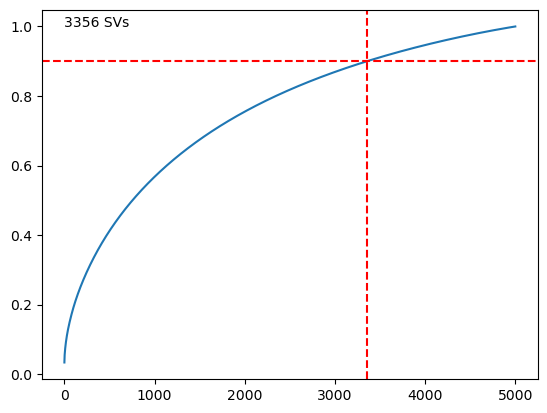

In [17]:
energy = svd.singular_values_**2
energy_ratio = energy / energy.sum()
energy_ratio_cumsum = energy_ratio.cumsum()

plt.plot([i for i in range(1,len(energy_ratio_cumsum)+1)], energy_ratio_cumsum)
plt.axhline(0.9, color='r', linestyle='--')

thresh = 0
for i in range(len(energy_ratio_cumsum)):
    if energy_ratio_cumsum[i] >= 0.9:
        plt.axvline(i+1, color='r', linestyle='--')
        plt.text(0, 1, f'{i+1} SVs')
        thresh = i+1
        print(f"Explained variance at {i+1} SVs: {energy_ratio_cumsum[i]:.2f}")
        break

# Brit's original section

preprocessing functions

In [71]:
def preprocess_basic(text):
    """
    Basic preprocessing:
    - fixes HTML symbols
    - lowercases text
    - removes non-letter characters
    - removes extra spaces
    """
    text = html.unescape(str(text))
    text = text.lower()
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def preprocess_no_short_words(text):
    """
    Basic preprocessing + removes words with 2 characters or fewer.
    """
    text = preprocess_basic(text)
    words = text.split()
    words = [word for word in words if len(word) > 2]
    return " ".join(words)


def preprocess_remove_game_words(text):
    """
    Removes common game-related words that may be too repetitive.
    """
    text = preprocess_no_short_words(text)

    custom_stopwords = {
        "game", "games", "role", "playing", "player", "players",
        "character", "characters", "rule", "rules", "system",
        "board", "card", "cards", "dice", "play"
    }

    words = text.split()
    words = [word for word in words if word not in custom_stopwords]
    return " ".join(words)

In [72]:
# apply preprocessing

combined_df["text_basic"] = combined_df["description"].apply(preprocess_basic)
combined_df["text_no_short"] = combined_df["description"].apply(preprocess_no_short_words)
combined_df["text_custom_stopwords"] = combined_df["description"].apply(preprocess_remove_game_words)

combined_df[["title", "type", "text_basic", "text_no_short", "text_custom_stopwords"]].head()

,title,type,text_basic,text_no_short,text_custom_stopwords
0,The Strange,TTRPG,publisher blurb beneath the orbits and atoms o...,publisher blurb beneath the orbits and atoms o...,publisher blurb beneath the orbits and atoms o...
1,InSpectres,TTRPG,fighting the forces of darkness so you don t h...,fighting the forces darkness you don have insp...,fighting the forces darkness you don have insp...
2,Dungeons & Dragons Expert Set,TTRPG,the first version of the d d expert set it con...,the first version the expert set contains page...,the first version the expert set contains page...
3,The Character Compendium,TTRPG,an unofficial supplement for warhammer fantasy...,unofficial supplement for warhammer fantasy ro...,unofficial supplement for warhammer fantasy ro...
4,The Elves of Alfheim,TTRPG,this is the first gazetteer to outline a non h...,this the first gazetteer outline non human cul...,this the first gazetteer outline non human cul...


try qs code

In [93]:
!pip install contractions

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [contractions]


In [100]:
import nltk
nltk.download("punkt_tab")

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/brittanyuy/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [103]:
import html
import contractions

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

from sklearn.feature_extraction.text import TfidfVectorizer

# Run these once if needed
nltk.download("punkt")
nltk.download("stopwords")
nltk.download("wordnet")

# Use the merged dataset descriptions
descs = combined_df["description"].astype(str).tolist()

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def nltk_text_preprocessor(text):
    # format text
    text = html.unescape(str(text))

    # expand contractions
    text = contractions.fix(text)

    # tokenize
    tokens = word_tokenize(text.lower())

    # remove stopwords + lemmatize + keep words longer than 2 chars
    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word.isalpha() and word not in stop_words and len(word) > 2
    ]

    return tokens

tokenized_corpus = [nltk_text_preprocessor(doc) for doc in descs]

processed_corpus = [
    " ".join(tokens)
    for tokens in tokenized_corpus
]

# Save NLTK-preprocessed text as a new column
combined_df["text_nltk"] = processed_corpus

tfidf_vectorizer = TfidfVectorizer(
    token_pattern=r"\w+",
    lowercase=True,
    min_df=5,
)

tfidf_vectorizer.fit(processed_corpus)

df_tfidf = pd.DataFrame.sparse.from_spmatrix(
    tfidf_vectorizer.transform(processed_corpus),
    columns=tfidf_vectorizer.get_feature_names_out(),
)

df_tfidf.shape

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/brittanyuy/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/brittanyuy/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/brittanyuy/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


(18645, 15483)

In [102]:
{
    "experiment_name": "NLTK preprocessing + unigram TF-IDF",
    "text_column": "text_nltk",
    "min_df": 5,
    "ngram_range": (1, 1)
}

{'experiment_name': 'NLTK preprocessing + unigram TF-IDF',
 'text_column': 'text_nltk',
 'min_df': 5,
 'ngram_range': (1, 1)}

In [ ]:
svd = TruncatedSVD(n_components=df_tfidf.shape[1])
svd.fit(df_tfidf)

In [73]:
# Use sampled data for faster experimentation
# This keeps the experiment manageable while still including both TTRPGs and board games.

sample_size = min(5000, len(combined_df))

sampled_df = combined_df.sample(
    n=sample_size,
    random_state=42
).reset_index(drop=True)

print("Sampled shape:", sampled_df.shape)
print(sampled_df["type"].value_counts())

sampled_df.head()

Sampled shape: (5000, 8)
type
TTRPG         2603
Board Game    2397
Name: count, dtype: int64


,title,description,average_score,number_of_reviews,type,text_basic,text_no_short,text_custom_stopwords
0,Abomination Vaults Pawn Collection,Publisher's blurb: Dungeon denizens from the A...,8.00000,1.0,TTRPG,publisher s blurb dungeon denizens from the ab...,publisher blurb dungeon denizens from the abom...,publisher blurb dungeon denizens from the abom...
1,Hansa,Players are merchants of the Hanseatic League....,6.88000,NaN,Board Game,players are merchants of the hanseatic league ...,players are merchants the hanseatic league pla...,are merchants the hanseatic league take contro...
2,Pimp: The Backhanding,From the publisher:&#10;&#10;Forget growing up...,5.19000,NaN,Board Game,from the publisher forget growing up to be a f...,from the publisher forget growing fireman cop ...,from the publisher forget growing fireman cop ...
3,Spellslinger,Publisher Blurb: This self-contained d20 mini-...,5.75000,4.0,TTRPG,publisher blurb this self contained d mini rpg...,publisher blurb this self contained mini rpg t...,publisher blurb this self contained mini rpg t...
4,Karma Sourcebook,"Karma details the heart of Stormer products, t...",8.05882,17.0,TTRPG,karma details the heart of stormer products th...,karma details the heart stormer products the p...,karma details the heart stormer products the p...


In [74]:
# svd experiment function
def run_svd_experiment(
    text_data,
    experiment_name,
    min_df=5,
    ngram_range=(1, 1),
    variance_threshold=0.90,
    component_cap=300
):
    """
    Runs TF-IDF + TruncatedSVD on text data.
    No max_features limit is used so TF-IDF keeps all eligible terms.
    """

    vectorizer = TfidfVectorizer(
        stop_words="english",
        lowercase=True,
        min_df=min_df,
        ngram_range=ngram_range
    )

    X_tfidf = vectorizer.fit_transform(text_data)

    max_components = min(
        X_tfidf.shape[0] - 1,
        X_tfidf.shape[1] - 1,
        component_cap
    )

    svd = TruncatedSVD(
        n_components=max_components,
        random_state=42,
        n_iter=5
    )

    X_svd = svd.fit_transform(X_tfidf)

    cumulative_variance = svd.explained_variance_ratio_.cumsum()
    reached_threshold = cumulative_variance[-1] >= variance_threshold

    if reached_threshold:
        retained_svs = np.argmax(cumulative_variance >= variance_threshold) + 1
    else:
        retained_svs = max_components

    result = {
        "experiment": experiment_name,
        "min_df": min_df,
        "ngram_range": str(ngram_range),
        "tfidf_rows": X_tfidf.shape[0],
        "tfidf_features": X_tfidf.shape[1],
        "components_tested": max_components,
        "reached_90_percent": reached_threshold,
        "retained_svs": retained_svs,
        "explained_variance_at_retained_svs": cumulative_variance[retained_svs - 1],
        "max_explained_variance_tested": cumulative_variance[-1]
    }

    return result, vectorizer, svd, X_tfidf, X_svd, cumulative_variance

run preprocessing experiments on sampled data

In [75]:
experiments = []
saved_outputs = {}

experiment_settings = [
    {
        "experiment_name": "Basic + unigram TF-IDF",
        "text_column": "text_basic",
        "min_df": 5,
        "ngram_range": (1, 1)
    },
    {
        "experiment_name": "No short words + unigram TF-IDF",
        "text_column": "text_no_short",
        "min_df": 5,
        "ngram_range": (1, 1)
    },
    {
        "experiment_name": "Custom stopwords + unigram TF-IDF",
        "text_column": "text_custom_stopwords",
        "min_df": 5,
        "ngram_range": (1, 1)
    },
    {
        "experiment_name": "Basic + unigram/bigram TF-IDF",
        "text_column": "text_basic",
        "min_df": 5,
        "ngram_range": (1, 2)
    }
]

for setting in experiment_settings:
    print("Running:", setting["experiment_name"])

    result, vectorizer, svd, X_tfidf, X_svd, cumulative_variance = run_svd_experiment(
        text_data=sampled_df[setting["text_column"]],
        experiment_name=setting["experiment_name"],
        min_df=setting["min_df"],
        ngram_range=setting["ngram_range"],
        component_cap=300
    )

    experiments.append(result)

    saved_outputs[setting["experiment_name"]] = {
        "vectorizer": vectorizer,
        "svd": svd,
        "X_tfidf": X_tfidf,
        "X_svd": X_svd,
        "cumulative_variance": cumulative_variance,
        "text_column": setting["text_column"]
    }

results_df = pd.DataFrame(experiments)

results_df.sort_values(
    by=["reached_90_percent", "retained_svs", "max_explained_variance_tested"],
    ascending=[False, True, False]
)

Running: Basic + unigram TF-IDF
Running: No short words + unigram TF-IDF
Running: Custom stopwords + unigram TF-IDF
Running: Basic + unigram/bigram TF-IDF


,experiment,min_df,ngram_range,tfidf_rows,tfidf_features,components_tested,reached_90_percent,retained_svs,explained_variance_at_retained_svs,max_explained_variance_tested
1,No short words + unigram TF-IDF,5,"(1, 1)",5000,8744,300,False,300,0.315505,0.315505
0,Basic + unigram TF-IDF,5,"(1, 1)",5000,8843,300,False,300,0.314493,0.314493
2,Custom stopwords + unigram TF-IDF,5,"(1, 1)",5000,8729,300,False,300,0.303476,0.303476
3,Basic + unigram/bigram TF-IDF,5,"(1, 2)",5000,14036,300,False,300,0.282322,0.282322


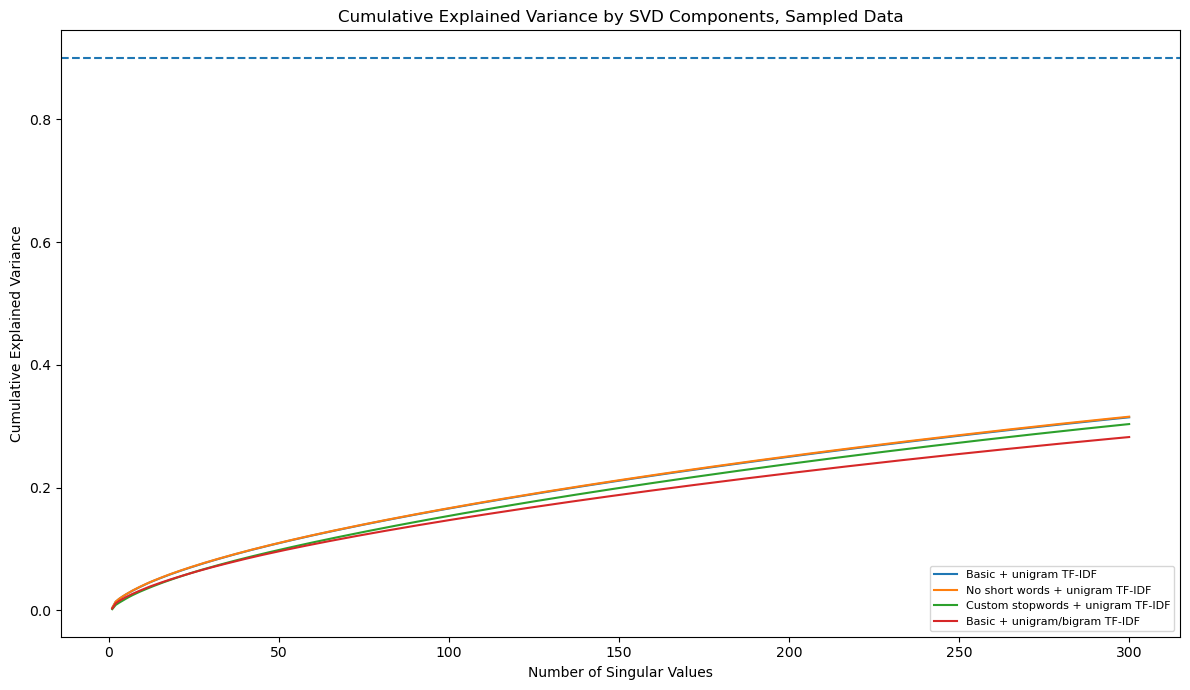

In [76]:
#plot sampled experiment results

plt.figure(figsize=(12, 7))

for experiment_name, output in saved_outputs.items():
    cumulative_variance = output["cumulative_variance"]

    plt.plot(
        range(1, len(cumulative_variance) + 1),
        cumulative_variance,
        label=experiment_name
    )

plt.axhline(0.90, linestyle="--")

plt.title("Cumulative Explained Variance by SVD Components, Sampled Data")
plt.xlabel("Number of Singular Values")
plt.ylabel("Cumulative Explained Variance")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

pick best method for sampled experiments

In [77]:
# If any experiment reaches 90%, choose the one with the fewest retained SVs.
# If none reaches 90%, choose the one with highest explained variance.

if results_df["reached_90_percent"].any():
    best_experiment_name = (
        results_df[results_df["reached_90_percent"] == True]
        .sort_values(by="retained_svs", ascending=True)
        .iloc[0]["experiment"]
    )
else:
    best_experiment_name = (
        results_df
        .sort_values(by="max_explained_variance_tested", ascending=False)
        .iloc[0]["experiment"]
    )

print("Best sampled experiment:", best_experiment_name)

best_sampled_setting = next(
    setting for setting in experiment_settings
    if setting["experiment_name"] == best_experiment_name
)

best_sampled_setting

Best sampled experiment: No short words + unigram TF-IDF


{'experiment_name': 'No short words + unigram TF-IDF',
 'text_column': 'text_no_short',
 'min_df': 5,
 'ngram_range': (1, 1)}

In [78]:
# Apply the highest-performing sampled method to the full merged dataset.
full_result, full_vectorizer, full_svd, full_X_tfidf, full_X_svd, full_cumvar = run_svd_experiment(
    text_data=combined_df[best_sampled_setting["text_column"]],
    experiment_name=best_sampled_setting["experiment_name"] + " applied to full dataset",
    min_df=best_sampled_setting["min_df"],
    ngram_range=best_sampled_setting["ngram_range"],
    component_cap=700
)

full_result

{'experiment': 'No short words + unigram TF-IDF applied to full dataset',
 'min_df': 5,
 'ngram_range': '(1, 1)',
 'tfidf_rows': 18645,
 'tfidf_features': 18237,
 'components_tested': 700,
 'reached_90_percent': np.False_,
 'retained_svs': 700,
 'explained_variance_at_retained_svs': np.float64(0.3748992809466462),
 'max_explained_variance_tested': np.float64(0.3748992809466462)}

Plot full dataset SVD result

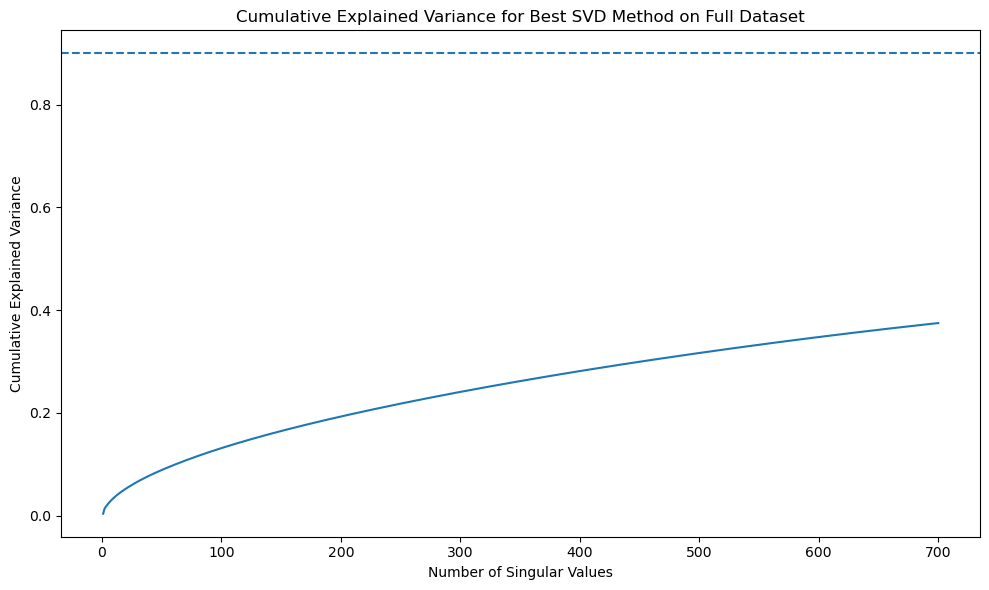

In [79]:
plt.figure(figsize=(10, 6))

plt.plot(
    range(1, len(full_cumvar) + 1),
    full_cumvar
)

plt.axhline(0.90, linestyle="--")

plt.title("Cumulative Explained Variance for Best SVD Method on Full Dataset")
plt.xlabel("Number of Singular Values")
plt.ylabel("Cumulative Explained Variance")
plt.tight_layout()
plt.show()

Store final best model objects

In [80]:
best_vectorizer = full_vectorizer
best_svd = full_svd
best_X_tfidf = full_X_tfidf
best_X_svd = full_X_svd
best_cumulative_variance = full_cumvar
best_text_column = best_sampled_setting["text_column"]

print("Final best text column:", best_text_column)
print("Final full dataset result:")
full_result

Final best text column: text_no_short
Final full dataset result:


{'experiment': 'No short words + unigram TF-IDF applied to full dataset',
 'min_df': 5,
 'ngram_range': '(1, 1)',
 'tfidf_rows': 18645,
 'tfidf_features': 18237,
 'components_tested': 700,
 'reached_90_percent': np.False_,
 'retained_svs': 700,
 'explained_variance_at_retained_svs': np.float64(0.3748992809466462),
 'max_explained_variance_tested': np.float64(0.3748992809466462)}

Create TF-IDF dataframe for final model

In [81]:
best_tfidf_df = pd.DataFrame.sparse.from_spmatrix(
    best_X_tfidf,
    columns=best_vectorizer.get_feature_names_out()
)

best_tfidf_df.head()

,aaa,aada,aaron,aasimar,abacus,abandon,abandoned,abbey,abbeys,abbot,...,zombies,zonas,zone,zones,zoo,zoom,zum,zur,zwischen,zwyci
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [82]:
#optional with titles
best_tfidf_df_with_titles = pd.concat(
    [
        combined_df[["title", "type"]].reset_index(drop=True),
        best_tfidf_df.reset_index(drop=True)
    ],
    axis=1
)

best_tfidf_df_with_titles.head()

,title,type,aaa,aada,aaron,aasimar,abacus,abandon,abandoned,abbey,...,zombies,zonas,zone,zones,zoo,zoom,zum,zur,zwischen,zwyci
0,The Strange,TTRPG,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,InSpectres,TTRPG,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,Dungeons & Dragons Expert Set,TTRPG,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,The Character Compendium,TTRPG,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,The Elves of Alfheim,TTRPG,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Create SVD semantic vectors dataframe

In [83]:
best_svd_df = pd.DataFrame(
    best_X_svd,
    columns=[f"SV {i+1}" for i in range(best_X_svd.shape[1])]
)

best_svd_df_with_titles = pd.concat(
    [
        combined_df[["title", "type"]].reset_index(drop=True),
        best_svd_df.reset_index(drop=True)
    ],
    axis=1
)

best_svd_df_with_titles.head()

,title,type,SV 1,SV 2,SV 3,SV 4,SV 5,SV 6,SV 7,SV 8,...,SV 691,SV 692,SV 693,SV 694,SV 695,SV 696,SV 697,SV 698,SV 699,SV 700
0,The Strange,TTRPG,0.077834,-0.072374,0.007821,0.056836,-0.057898,-0.013907,0.049250,0.003460,...,0.003548,0.015293,0.001071,-0.007656,-0.008876,-0.002777,-0.005870,-0.008742,-0.025559,0.004654
1,InSpectres,TTRPG,0.127388,-0.029610,-0.028215,-0.054024,-0.026076,0.009881,0.023887,-0.045080,...,-0.012414,-0.011108,0.001631,0.003144,0.008497,0.010611,0.011905,-0.015608,0.001232,0.006087
2,Dungeons & Dragons Expert Set,TTRPG,0.208631,-0.152861,0.027266,-0.048926,0.232956,-0.102548,-0.005492,-0.089847,...,-0.006870,-0.011993,0.001695,0.013121,0.016521,0.018753,0.014257,0.002101,-0.009971,0.029769
3,The Character Compendium,TTRPG,0.099072,-0.106330,0.051090,-0.077016,0.048668,0.081904,-0.035507,0.041958,...,-0.004076,0.005808,0.003641,0.012407,0.022575,0.026692,0.004571,-0.004585,-0.011437,0.037319
4,The Elves of Alfheim,TTRPG,0.096078,-0.051711,0.006946,0.039562,-0.022779,0.012621,-0.010272,0.023423,...,-0.007335,-0.016505,-0.014255,0.006974,-0.003166,-0.014766,-0.008464,-0.005822,-0.004292,0.004154


In [84]:
# IR search function

def search_games(query, text_preprocessor, vectorizer, svd, game_vectors, df, top_n=10):
    """
    Search for games similar to a user query using TF-IDF + SVD vectors.
    """

    clean_query = text_preprocessor(query)

    query_tfidf = vectorizer.transform([clean_query])
    query_svd = svd.transform(query_tfidf)

    similarities = cosine_similarity(query_svd, game_vectors).flatten()

    results = df[[
        "title",
        "type",
        "description",
        "average_score",
        "number_of_reviews"
    ]].copy()

    results["similarity"] = similarities

    return results.sort_values("similarity", ascending=False).head(top_n)

In [85]:
# Map final preprocessor

preprocessor_map = {
    "text_basic": preprocess_basic,
    "text_no_short": preprocess_no_short_words,
    "text_custom_stopwords": preprocess_remove_game_words
}

best_preprocessor = preprocessor_map[best_text_column]

print("Best preprocessor:", best_text_column)

Best preprocessor: text_no_short


test IR queries

In [86]:
search_games(
    query="fantasy adventure with magic dragons and quests",
    text_preprocessor=best_preprocessor,
    vectorizer=best_vectorizer,
    svd=best_svd,
    game_vectors=best_X_svd,
    df=combined_df,
    top_n=10
)

,title,type,description,average_score,number_of_reviews,similarity
3316,Fantasy Hero 4th Edition,TTRPG,Publisher's description: Fantasy comes to the ...,6.80769,13.0,0.523679
3145,The Art of the Advanced Dungeons & Dragons Fan...,TTRPG,The Art of the Advanced Dungeons & Dragons Fan...,0.00000,0.0,0.472559
1123,Fantasy Wargaming: The Highest Level of All,TTRPG,From the dust jacket: Fantasy Wargaming - Comp...,4.10000,46.0,0.467509
7346,Fantasy Hero 6th Edition,TTRPG,Back Cover: WONDROUS WORLDS OF FANTASY! Fantas...,8.21429,7.0,0.467260
228,Dungeons & Dragons Basic Rulebook (Second Edit...,TTRPG,From the back of the book: DUNGEONS & DRAGONS ...,7.99107,28.0,0.464092
8884,Wizards & Spells: A Young Adventurer's Guide,TTRPG,Publisher's blurb: An immersive illustrated pr...,2.00000,1.0,0.464045
2908,Dragon Keep,TTRPG,From the back cover: The good dragons of Krynn...,6.20000,5.0,0.450737
925,Dungeons & Dragons Basic Set (Second Edition),TTRPG,"From the back of the box: ""Fire and smoke surr...",8.09080,250.0,0.446236
7334,Draconomicon: Metallic Dragons,TTRPG,Draconomicon: Metallic Dragons describes sever...,7.21212,33.0,0.441260
4861,A Magical Medley (Fudge),TTRPG,A Magical Medley is a magic-rich supplement fo...,7.83333,6.0,0.441139


In [87]:
search_games(
    query="horror mystery investigation supernatural monsters",
    text_preprocessor=best_preprocessor,
    vectorizer=best_vectorizer,
    svd=best_svd,
    game_vectors=best_X_svd,
    df=combined_df,
    top_n=10
)

,title,type,description,average_score,number_of_reviews,similarity
7646,GURPS Horror (Fourth Edition),TTRPG,It's back . . . and the fear has grown! GURPS ...,8.28125,16.0,0.532887
5260,Nightmares of Mine,TTRPG,[Back cover] Horror has been with us for as lo...,8.73333,12.0,0.470990
6338,Ghost Stories: Horror Mystery Adventures,TTRPG,From publisher blurb: Ghost Stories is predica...,7.00000,1.0,0.453425
7323,Supernatural Adventures,TTRPG,"You've Got Work To Do! Ghosts, demons, and mon...",6.00000,1.0,0.451471
8540,English Eerie,TTRPG,Rural Horror Storytelling Game for One Player ...,7.03333,3.0,0.447624
9546,The Ocean Game,TTRPG,Publisher Blurb: The Ocean Game. A rumour in t...,0.00000,0.0,0.435088
9477,Lovecraftesque Second Edition,TTRPG,Lovecraftesque is a storytelling card game of ...,7.70000,5.0,0.430631
2584,Beyond the Supernatural (First Edition),TTRPG,From the back of the book: A Role-Playing Game...,6.00000,26.0,0.420089
6919,Mortal Coil,TTRPG,Mortal Coil is a supernatural role-playing gam...,8.00000,5.0,0.411196
7007,Fear Itself,TTRPG,Fear Itself plunges ordinary people into a dis...,7.12400,25.0,0.406389


In [88]:
search_games(
    query="science fiction space exploration cyberpunk future technology",
    text_preprocessor=best_preprocessor,
    vectorizer=best_vectorizer,
    svd=best_svd,
    game_vectors=best_X_svd,
    df=combined_df,
    top_n=10
)

,title,type,description,average_score,number_of_reviews,similarity
984,Space Opera,TTRPG,Space Opera is a science-fiction role-playing ...,6.29200,25.0,0.492559
3268,Buck Rogers Boxed Set XXVc,TTRPG,Buck Rogers and the forces of the New Earth Or...,7.61765,17.0,0.466231
9133,Cepheus Deluxe,TTRPG,Publisher's blurb: Starships riding fire acros...,8.00000,5.0,0.458216
6384,OGL Steampunk,TTRPG,From the back of the book: This is the world o...,5.00000,2.0,0.454947
173,Genesys Core Rulebook,TTRPG,Description from the publisher: Face down a dr...,8.09615,52.0,0.446860
4961,High Tech and Low Life,TTRPG,Blurb from back cover: The world of Shadowrun ...,6.18182,11.0,0.426628
9436,Cepheus Universal,TTRPG,Cepheus Universal is a 443 page game of univer...,9.00000,5.0,0.421766
9046,Coyote & Crow,TTRPG,"Publisher's description: Coyote & Crow, the Ro...",6.80000,5.0,0.420839
3367,GURPS Aliens,TTRPG,"From the cover: ""Nonhuman Races for Science Fi...",6.40909,11.0,0.419853
3026,GURPS Space (Second Edition),TTRPG,"Subtitle: ""Roleplaying in the Worlds of Tomorr...",7.04545,33.0,0.416400


In [89]:
search_games(
    query="strategy war civilization resource management combat",
    text_preprocessor=best_preprocessor,
    vectorizer=best_vectorizer,
    svd=best_svd,
    game_vectors=best_X_svd,
    df=combined_df,
    top_n=10
)

,title,type,description,average_score,number_of_reviews,similarity
9892,Sid Meier's Civilization: The Board Game,Board Game,Please note: this entry covers the 2010 releas...,7.40,NaN,0.441198
11233,Age of Renaissance,Board Game,A game that is often described as a semi-seque...,7.10,NaN,0.410242
11901,Age of Civilization,Board Game,"In the Age of Civilization, you must lead your...",7.13,NaN,0.382317
12577,Mega Civilization,Board Game,Description from the publisher:&#10;&#10;Mega ...,8.24,NaN,0.378806
10188,Civilization,Board Game,Civilization is a game of skill for 2 to 7 pla...,7.50,NaN,0.377124
18014,"Outreach: The Conquest of the Galaxy, 3000AD",Board Game,"Simulates civilization development, intra-gala...",6.56,NaN,0.372312
10955,Sid Meier's Civilization: The Boardgame,Board Game,This entry covers the 2002 release of Sid Meie...,5.60,NaN,0.344141
15309,Nile,Board Game,Nile the card game consists of 92 cards. There...,6.10,NaN,0.342056
12482,7 Ages,Board Game,7 Ages is a game of world history from 4000 BC...,7.07,NaN,0.337537
11071,Washington's War,Board Game,(from GMT's website:)&#10;&#10;Washington&rsqu...,7.63,NaN,0.333630


In [90]:
summary_table = pd.concat(
    [
        results_df.assign(stage="sampled_experiment"),
        pd.DataFrame([full_result]).assign(stage="full_dataset_best_method")
    ],
    ignore_index=True
)

summary_table

,experiment,min_df,ngram_range,tfidf_rows,tfidf_features,components_tested,reached_90_percent,retained_svs,explained_variance_at_retained_svs,max_explained_variance_tested,stage
0,Basic + unigram TF-IDF,5,"(1, 1)",5000,8843,300,False,300,0.314493,0.314493,sampled_experiment
1,No short words + unigram TF-IDF,5,"(1, 1)",5000,8744,300,False,300,0.315505,0.315505,sampled_experiment
2,Custom stopwords + unigram TF-IDF,5,"(1, 1)",5000,8729,300,False,300,0.303476,0.303476,sampled_experiment
3,Basic + unigram/bigram TF-IDF,5,"(1, 2)",5000,14036,300,False,300,0.282322,0.282322,sampled_experiment
4,No short words + unigram TF-IDF applied to ful...,5,"(1, 1)",18645,18237,700,False,700,0.374899,0.374899,full_dataset_best_method
